In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#### Tugas 1 Hapus noise speckle pada gambar 1 dan 3

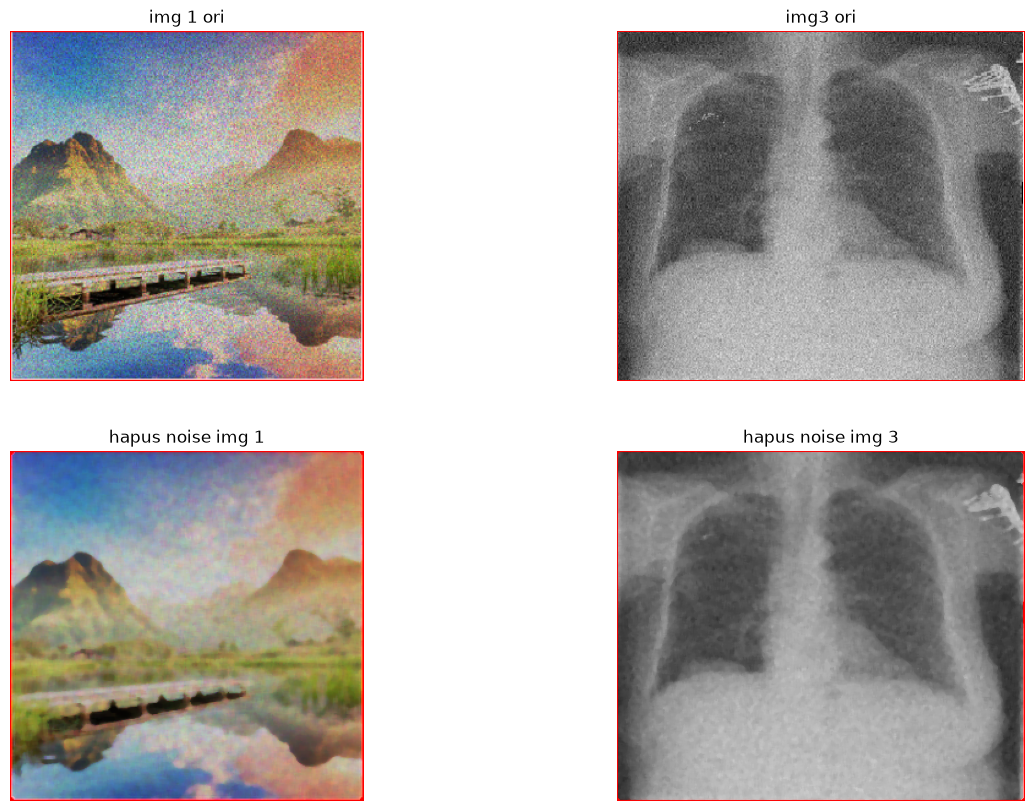

In [3]:
img1 = cv2.imread("tugas 1.png")
img3 = cv2.imread("tugas 3.png")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

denoised_img1 = cv2.medianBlur(img1, 5)
denoised_img3 = cv2.medianBlur(img3, 5)

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(img1)
plt.title("img 1 ori")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(denoised_img1)
plt.title("hapus noise img 1")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(img3)
plt.title("img3 ori")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(denoised_img3)
plt.title("hapus noise img 3")
plt.axis("off")

plt.show()

#### Tugas 2 Hapus noise anotasi pada gambar 2

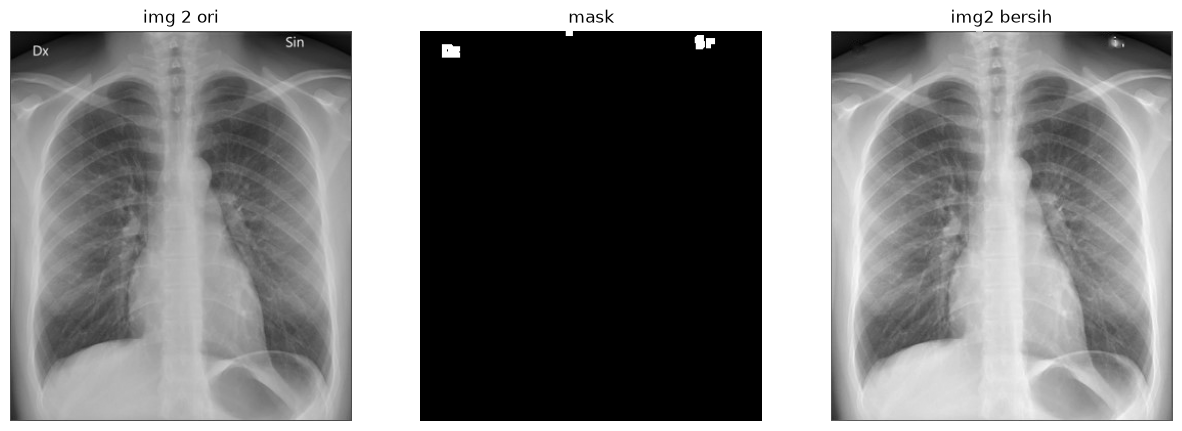

In [4]:
img2 = cv2.imread("tugas 2.jpg", cv2.IMREAD_GRAYSCALE)

mask = np.zeros_like(img2)

_, mask_dx = cv2.threshold(img2[:50, :150], 180, 255, cv2.THRESH_BINARY)
_, mask_sin = cv2.threshold(img2[:50, -150:], 180, 255, cv2.THRESH_BINARY)
mask[:50, :150] = mask_dx
mask[:50, -150:] = mask_sin

kernel = np.ones((5,5), np.uint8)
mask = cv2.dilate(mask, kernel, iterations=1)

cleaned_img2 = cv2.inpaint(img2, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

plt.figure(figsize=(15,10))

plt.subplot(1,3,1)
plt.imshow(img2, cmap="gray")
plt.title("img 2 ori")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cleaned_img2, cmap="gray")
plt.title("img2 bersih")
plt.axis("off")

plt.show()

#### Tugas 3 image enhancement

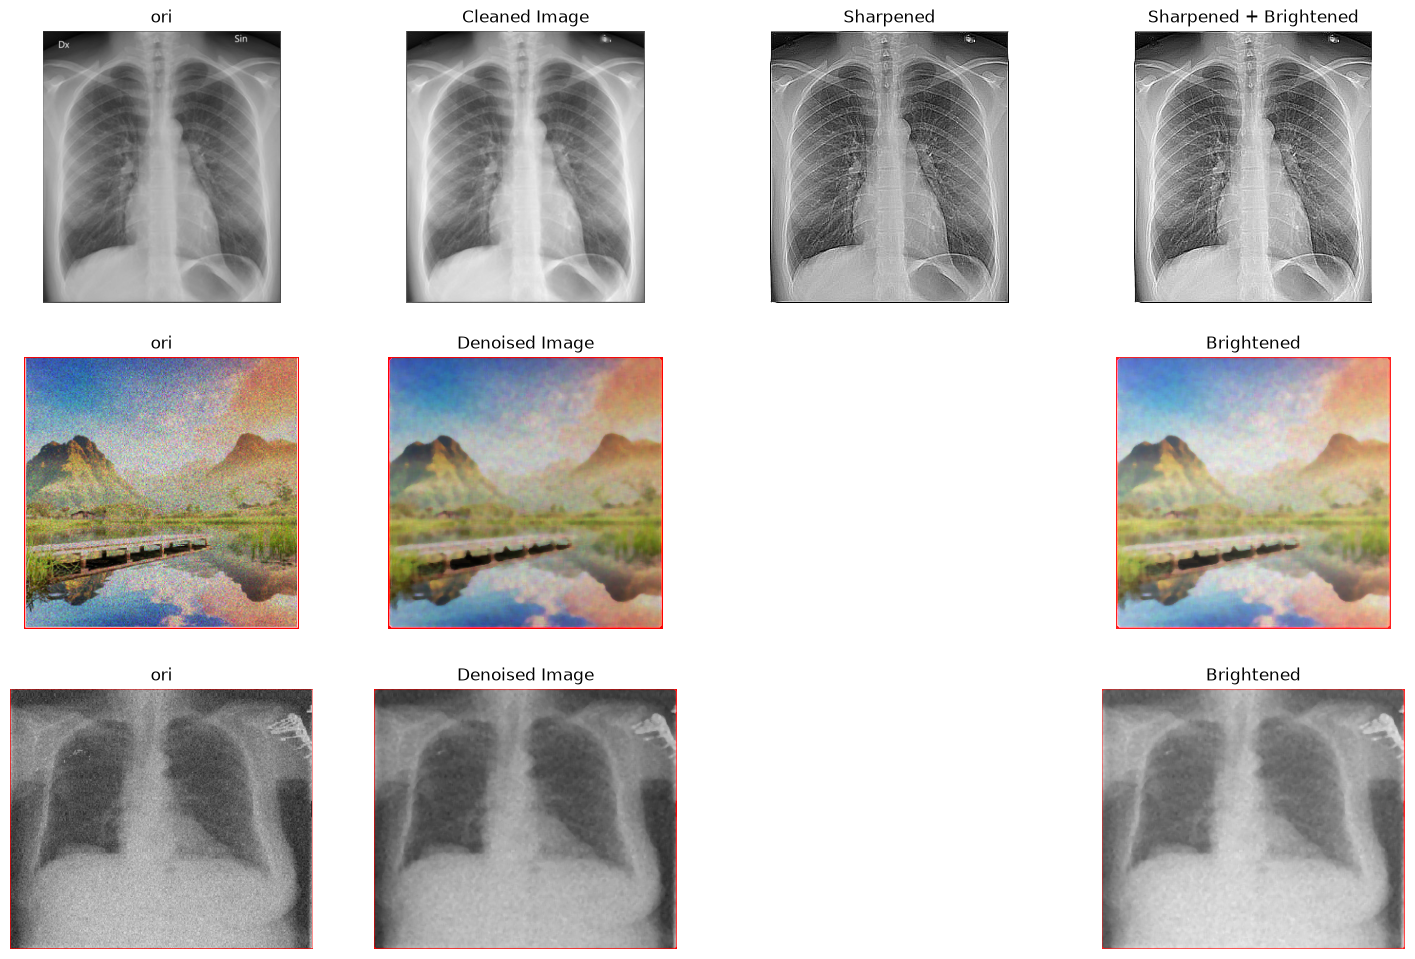

In [13]:
# gambar 2
kernel_sharpening = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])
sharpened_img2 = cv2.filter2D(cleaned_img2, -1, kernel_sharpening)

brightness_value = 30 
brightened_img2 = cv2.convertScaleAbs(sharpened_img2, alpha=1.0, beta=brightness_value)


# gambar 1
kernel_sharpening = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])

brightness_value = 30 
brightened_img1 = cv2.convertScaleAbs(denoised_img1, alpha=1.0, beta=brightness_value)

# gambar 3
kernel_sharpening = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])

brightness_value = 30 
brightened_img3 = cv2.convertScaleAbs(denoised_img3, alpha=1.0, beta=brightness_value)

plt.figure(figsize=(18, 12))

plt.subplot(3, 4, 1)
plt.imshow(img2, cmap="gray")
plt.title("ori")
plt.axis("off")

plt.subplot(3, 4, 2)
plt.imshow(cleaned_img2, cmap="gray")
plt.title("Cleaned Image")
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(sharpened_img2, cmap="gray")
plt.title("Sharpened")
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(brightened_img2, cmap="gray")
plt.title(f"Sharpened + Brightened")
plt.axis("off")

# gambar 1
plt.subplot(3, 4, 5)
plt.imshow(img1, cmap="gray")
plt.title("ori")
plt.axis("off")

plt.subplot(3, 4, 6)
plt.imshow(denoised_img1, cmap="gray")
plt.title("Denoised Image")
plt.axis("off")

plt.subplot(3, 4, 8)
plt.imshow(brightened_img1, cmap="gray")
plt.title(f"Brightened")
plt.axis("off")

# gambar 3
plt.subplot(3, 4, 9)
plt.imshow(img3, cmap="gray")
plt.title("ori")
plt.axis("off")

plt.subplot(3, 4, 10)
plt.imshow(denoised_img3, cmap="gray")
plt.title("Denoised Image")
plt.axis("off")

plt.subplot(3, 4, 12)
plt.imshow(brightened_img3, cmap="gray")
plt.title(f"Brightened")
plt.axis("off")

plt.show()

#### Tugas 4 Image Augmentation

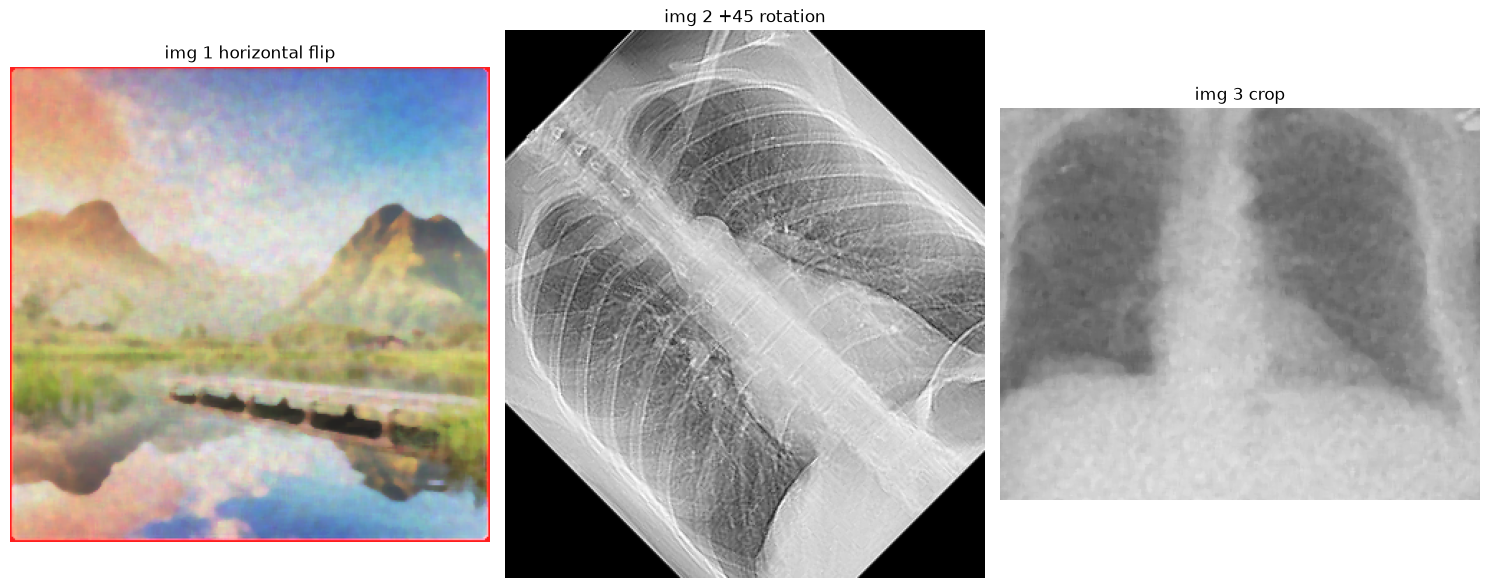

In [16]:
# img 1 horizontal flip
aug_img1 = cv2.flip(brightened_img1, 1)

# img 2 +45 rotation
h2, w2 = brightened_img2.shape[:2]
M = cv2.getRotationMatrix2D((w2 // 2, h2 // 2), 45, 1.0)
aug_img2 = cv2.warpAffine(brightened_img2, M, (w2, h2))

# img 3 crop
h3, w3 = brightened_img3.shape[:2]
aug_img3 = brightened_img3[50:h3-50, 50:w3-50]

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(aug_img1)
plt.title("img 1 horizontal flip")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(aug_img2, cmap="gray")
plt.title("img 2 +45 rotation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(aug_img3, cmap="gray")
plt.title("img 3 crop")
plt.axis("off")

plt.tight_layout()
plt.show()